# Изучение рынка заведений общественного питания Москвы

# Цель исследования
Сформировать рекомендации для инвесторов фонда Shut Up and Take My Money по выбору формата заведения общественного питания (кафе, ресторан, бар и т. д.) и его ключевых параметров (расположение, меню, ценовая политика) на основе анализа рынка Москвы.

# Задачи исследования
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
 * Изучить распределение заведений по категориям;
 * Выявить список административных районов Москвы в данных, рассчитать распределение количества заведений по районам. Отдельно сделать срез по ЦАО и показать распределение категорий внутри него;
 * Рассчитать долю сетевых и несетевых заведений в целом и в разрезе категорий;
 * Изучить распределение количества посадочных мест, выявить аномалии и выбросы;
 * Посчитать средний рейтинг по каждой категории;
 * Изучить, с какими данными показывают самую сильную корреляцию рейтинг заведений. Выделить самую сильную корреляцию и проверить её дополнительно;
 * Сгруппировать по названию сети, отобрать топ‑15 по количеству заведений, посчитать для них средний рейтинг и определить преобладающие категории;
 * Проанализировать вариацию среднего чека (middle_avg_bill) по районам и понять есть ли зависимость между ценой и удалённостью от центра. 
4. Сформулировать выводы по проведённому анализу.

# Исходные данные
Для анализа используем данные о заведениях общественного питания Москвы, взятых из сервисов Яндекс Карт и Яндекс Бизнес за лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` — информация о среднем чеке в заведениях общественного питания.

***Описание датасета `rest_info`***

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например "кафе", "пиццерия" или "кофейня";
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка - 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
 * 0 - заведение не является сетевым;
 * 1 - заведение является сетевым.
- `seats` — количество посадочных мест;

***Описание датасета `rest_price`***

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например: 
 * «Средний счёт: 1000–1500 ₽»;
 * «Цена чашки капучино: 130–220 ₽»;
 * «Цена бокала пива: 400–600 ₽».
 * и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»: 
 * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
 * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
 * Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»: 
 * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
 * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
 * Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

<a id='start'></a>
# Содержание

***Часть 1. Изучение общей информации:***

[1.1 Загрузка данных и знакомство с ними](#intro)

[1.2 Подготовка единого датафрейма](#1)

***Часть 2. Предобработка данных:***

[2.1 Оптимизация типов данных](#2)

[2.2 Наличие пропусков в данных](#3)

[2.3 Явные и неявные дубликаты в данных](#4)

[2.4 Создание нового столбца для круглосуточных заведений](#5)

***Часть 3. Исследовательский анализ данных:***

[3.1 Распределение заведений по категориям](#6)

[3.2 Распределение заведений по административным районам Москвы](#7)

[3.3 Соотношение сетевых и несетевых заведений](#8)

[3.4 Исследование количества посадочных мест в заведениях](#9)

[3.5 Распределение рейтинга заведений по категориям](#10)

[3.6 Изучение корреляции между рейтингом заведений и другими данными](#11)

[3.7 Топ-15 популярных сетей в Москве](#12)

[3.8 Зависимость среднего чека от района Москвы](#13)

***Часть 4. Итоговые выводы***

[4.1 Обзор проделанной работы](#14)

[4.2 Ответы на исследовательские вопросы](#15)

[4.3 Рекомендации на основе анализа данных](#16)

---

# Часть 1. Изучение общей информации
<a id='intro'></a>
***1.1 Загрузка данных и знакомство с ними***

Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
!pip install phik -q

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phik
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('.csv')
price_df = pd.read_csv('.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
# Выводим первые строки датафрейма на экран
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:

* Названия столбцов отображаются корректно. 
* Шесть столбцов хранятся в типе данных `object`. Два столбца содержат числовые значения с типом данных `float64`. Столбец `chain` представлен целыми числами с типом данных `int64` и так как значения в нём 1 или 0 — размерность этих данных можно оптимизировать.
* Пропуски содержатся только в столбцах `hours` и `seats`.
* Значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов отображаются корректно.
- Типы данных соответствуют содержимому. 
- Пропуски есть во всех столбцах кроме `id`. В оценочных столбцах `middle_avg_bill` и `middle_coffee_cup` пропуски  ожидаемы,  они закономерно возникают из‑за логики расчёта (зависят от формулировок в `avg_bill`). 
- Значения в столбцах соответствуют описанию.

---

<a id='1'></a>
***1.2 Подготовка единого датафрейма***

Объединим данные двух датасетов в один, с которым в дальнейшем продолжим работу.

In [8]:
# Присоединим датафреймы методом merge() по общему столбцу id
df = pd.merge(info_df, price_df, on='id', how='left')

In [9]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


***ПРОМЕЖУТОЧНЫЙ ВЫВОД:*** Объединенный датафрейм пригоден для анализа - структура данных и названия столбцов соответствуют ожидаемым. Приступаем к следующему этапу — предобработка данных.

[Назад к содержанию](#start)

---

# Часть 2. Предобработка данных
<a id='2'></a>
***2.1 Оптимизация типов данных***

В столбце `chain` с целочисленным типом данных уменьшим разрядность методом `pd.to_numeric` с аргументом `downcast='integer'`:

In [10]:
# Оптимизируем целочисленный тип данных столбца chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

Столбец `seats` имеет тип данных `float64` вероятно из-за наличия пропусков и невозможности сохранения в `int64`. Для удобства дальнейшей обработки приведем к типу данных `Int16`, так как получим целочисленные значения, что лучше подходит для количества посадочных мест и уменьшим объем хранения данных.

In [11]:
# Преобразовываем тип данных столбца seats к типу int16 c обработкой пропусков
df['seats'] = df['seats'].astype('Int16')

In [12]:
# Проверяем результат преобразования
df[['chain', 'seats']].dtypes

chain     int8
seats    Int16
dtype: object

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

---

<a id='3'></a>
***2.2 Наличие пропусков в данных***

Посчитаем количество пропусков в каждом столбце в абсолютных и относительных значениях.

In [13]:
# Выводим количество пропущенных строк в датафрейме
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [14]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]*100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

Пропуски наблюдаем в 6 столбцах: `hours` - 6.4%, `seats` - 43.0%, `price` - 60.6%, `avg_bill` - 54.6%, `middle_avg_bill` - 62.5%, `middle_coffee_cup` - 93.6%.

Данные получены из открытых источников Яндекс Карт/Бизнес, поэтому наличие пропусков может объясняться разными причинами, например, карточки заведений заполнены не полностью, так как некоторые поля для заполнения не обязательны, или заполнены нестандартно, у заведений разные форматы, произошла неполная выгрузка данных, пользовательские правки или ошибки.

Для каждого столбца выберем оптимальный вариант обработки пропусков:
* `hours` - столбец, имеет не большое количество пропусков, но их удаление исказит доли по районам и категориям, поэтому оставим `Nan` как есть.
* В `price` оставим пропуски как отдельную категорию `«Не указано»`. Это сохранит все данные и даст возможность анализировать эту категорию отдельно.
* В `seats` пропуски не будем заполнять, при дальнейшем анализе сделаем срез только с известными значениями в этом столбце.
* `avg_bill` - пропуски в этом столбце можно объяснить тем, что многие не указывают "средний чек", а пишут про отдельные позиции. 54,6% - это слишком высокий процент пропусков для заполнения усредненными значениями без искажения данных, поэтому оставим их как есть. 
* В `middle_avg_bill` и `middle_coffee_cup` высокий процент пропусков не ошибка, а специфика данных столбцов с весьма узкими условиями. `middle_coffee_cup` имеет 93,6 % — это почти отсутствие данных, в наших задачах не стоит изучение "кофейной специализации", поэтому здесь оставим пропуски как есть, в `middle_avg_bill` также пропуски оставим, а анализировать будем только известные значения.

In [15]:
# Заменяем все пропуски в price на категорию 'Не известно'
df['price'] = df['price'].fillna('не известно')

В данном исследовании лучшим вариантом обработки пропусков будет зафиксировать факт пропуска и дальше работать с ним как с отдельным сегментом данных если понадобится, так как удаление или заполнение усредными значениями приведет к потере большого объема информации или сильному искажению данных.

---

<a id='4'></a>
***2.3 Явные и неявные дубликаты в данных***

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [16]:
# Проверяем полные дубликаты в датафрейме 
df.duplicated().sum()

0

В датафрейме нет полных дубликатов строк. Проверим неявные дубликаты по ключевым полям - `name + address`, чтобы избежать одного и того же заведения, попавшего в данные дважды, но сначала нормализуем данные в столбце с названиями заведения.

In [17]:
# Приводим name к нижнему регистру и убираем лишние пробелы
df['name_norm'] = df['name'].str.lower().str.strip()

# Ищем дубли по нормализованному имени и адресу
df.duplicated(subset=['name_norm', 'address']).sum()

3

Найдено три дубликата. Для дальнейшей обработки сначала посмотрим как они выглядят и совпадают ли данные в других столбцах для этих строк.

In [18]:
# Выведем повторяющиеся строки 
dup_rows = df[df.duplicated(subset=['name_norm', 'address'], keep=False)].sort_values(['name_norm', 'address'])

dup_rows[['name', 'name_norm', 'address', 'district', 'rating', 'seats']].head(6)

,name,name_norm,address,district,rating,seats
1430,More poke,more poke,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,4.2,188
1511,More Poke,more poke,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,4.2,188
2211,Раковарня Клешни и Хвосты,раковарня клешни и хвосты,"Москва, проспект Мира, 118",Северо-Восточный административный округ,4.4,150
2420,Раковарня Клешни и хвосты,раковарня клешни и хвосты,"Москва, проспект Мира, 118",Северо-Восточный административный округ,4.4,150
3091,Хлеб да Выпечка,хлеб да выпечка,"Москва, Ярцевская улица, 19",Западный административный округ,4.1,276
3109,Хлеб да выпечка,хлеб да выпечка,"Москва, Ярцевская улица, 19",Западный административный округ,4.1,276


Исходя из приведенных значений, делаем вывод, что эти строки задублировались полностью и их можно удалить.

In [19]:
# Удаляем дубликаты по name_norm и address, оставляем первую строку
df = df.drop_duplicates(subset=['name_norm', 'address'], keep='first').reset_index(drop=True)

Теперь проверим корректность написания категориальных значений в данных.

In [20]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['district', 'category', 'price', 'chain', 'rating']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'не известно' 'низкие' 'средние']

Уникальные значения в столбце chain:
[0 1]

Уникальные значения в столбце rating:
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5. ]



Все значения выглядят корректными. 

---

<a id='5'></a>
***2.4 Создание нового столбца для круглосуточных заведений***

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [21]:
# Создаём флаг is_24_7: True, если заведение работает ежедневно и круглосуточно
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

Проверим, что всё сработало

In [22]:
# Сколько 24/7 заведений нашлось
df['is_24_7'].sum()

730

In [23]:
# Посмотрим, какие строки попали в True (если есть)
print(df[df['is_24_7']][['name', 'hours', 'is_24_7']].head(10))

                  name                     hours  is_24_7
10      Great Room Bar  ежедневно, круглосуточно     True
17  Чайхана Беш-Бармак  ежедневно, круглосуточно     True
19             Пекарня  ежедневно, круглосуточно     True
24          Drive Café  ежедневно, круглосуточно     True
49             2U-Ту-Ю  ежедневно, круглосуточно     True
50              Шаурма  ежедневно, круглосуточно     True
54              Шашлык  ежедневно, круглосуточно     True
61           Кафе Лоза  ежедневно, круглосуточно     True
70           Гуава бар  ежедневно, круглосуточно     True
84    Meat Doner Kebab  ежедневно, круглосуточно     True


***ПРОМЕЖУТОЧНЫЙ ВЫВОД:***

В результате предобработки данных были выполнены следующие действия:

* Проведена оптимизация типов данных: в `seats` тип данных изменён с `float64` на `Int16`, а в `chain` с `int64` на `int8` для уменьшения объема хранения данных.
* Изучены пропуски в данных. Пропуски обнаружились в 6 столбцах, во избежания искажения и потери данных, пропуски оставили как есть. 
* Данные проверили на явные и неявные дубликаты — провели очистку от обнаруженных трех дубликатов. 
* Для удобства в дальнейшем анализе создали булевый столбец `is_24_7` для категоризации заведений: круглосуточное или нет.

[Назад к содержанию](#start)

---

#  Часть 3. Исследовательский анализ данных

<a id='6'></a>
***3.1 Распределение заведений по категориям***

Рассмотрим какие категории заведений представлены в данных и исследуем количество объектов общественного питания по каждой категории.

In [24]:
# Смотрим уникальные категории
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [25]:
# Проверяем распределение заведений по категориям 
category_counts = (df['category'].value_counts().reset_index().rename(columns={'index': 'category', 'category': 'count'}))

In [26]:
# Рассчитываем долю для каждой категории
category_counts['share_%'] = (category_counts['count'] / len(df) * 100).round(2)

In [27]:
# Выводим результат 
print('Распределение количества объектов по категориям:')
category_counts

Распределение количества объектов по категориям:


,category,count,share_%
0,кафе,2377,28.29
1,ресторан,2042,24.30
2,кофейня,1413,16.82
3,"бар,паб",764,9.09
4,пиццерия,633,7.53
5,быстрое питание,603,7.18
6,столовая,315,3.75
7,булочная,256,3.05


Визуализируем распределение в столбце `category` с помощью столбчатой диаграммы.

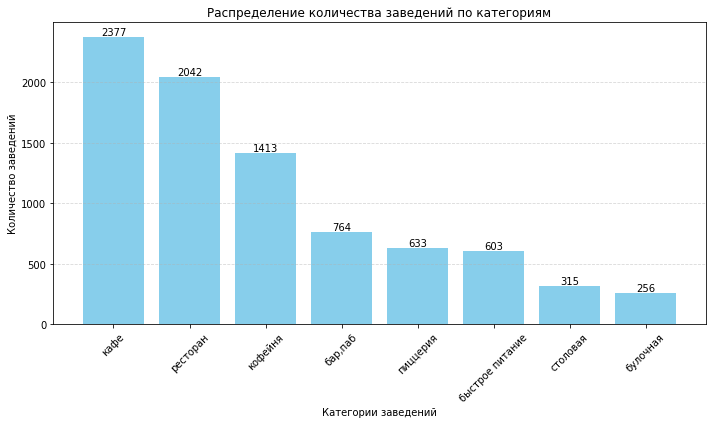

In [28]:
# Подготавливаем данные для графика
categories = category_counts['category']
counts = category_counts['count']

# Создаём фигуру и оси
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color='skyblue')

# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # координата X — центр столбца
        height,                             # координата Y — высота столбца
        f'{int(height)}',                   # текст метки
        ha='center',                        # горизонтальное выравнивание
        va='bottom',                        # вертикальное выравнивание (чуть ниже верхушки)
        fontsize=10
    )

# Оформление
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
plt.title('Распределение количества заведений по категориям')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Выводим график
plt.show()

Результаты показывают 8 уникальных категорий. Более половины заведений в выборке — это кафе и рестораны (52.6 %), следом значимо выделяется сегмент кофеен (16.8 %). Остальные форматы, включая быстрое питание, бары и пиццерии, представлены более равномерно, а столовые и булочные занимают минимальную долю рынка (6.8 % в сумме).

[Назад к содержанию](#start)

---
<a id='7'></a>
***3.2 Распределение заведений по административным районам Москвы***

Рассмотрим какие административные районы Москвы присутствуют в данных и исследуем распределение количества заведений по районам.

In [29]:
# Смотрим уникальные районы
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [30]:
# Проверяем распределение заведений по районам 
district_stats = (df['district'].value_counts()
                  .reset_index()
                  .rename(columns={'index': 'district', 'district': 'count'})
)

In [31]:
# Рассчитываем долю для каждого района
district_stats['share_%'] = (district_stats['count'] / len(df) * 100).round(2)

In [32]:
# Выводим результат
print('Распределение количества объектов по районам:')
district_stats

Распределение количества объектов по районам:


,district,count,share_%
0,Центральный административный округ,2242,26.68
1,Северный административный округ,899,10.70
2,Южный административный округ,892,10.62
3,Северо-Восточный административный округ,890,10.59
4,Западный административный округ,850,10.12
5,Восточный административный округ,798,9.50
6,Юго-Восточный административный округ,714,8.50
7,Юго-Западный административный округ,709,8.44
8,Северо-Западный административный округ,409,4.87


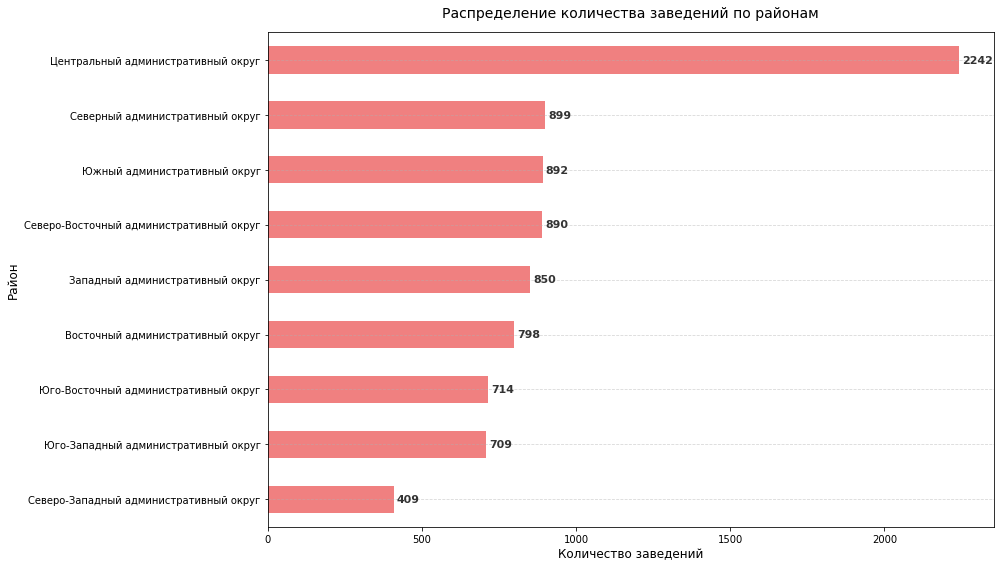

In [33]:
# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(14, 8))

# Строим график через pandas
district_stats.plot(
    x='district',
    y='count',
    kind='barh',
    color='lightcoral',
    legend=False,
    ax=ax  
)

# Настройка оформления
ax.set_title('Распределение количества заведений по районам', fontsize=14, pad=15)
ax.set_xlabel('Количество заведений', fontsize=12)
ax.set_ylabel('Район', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.invert_yaxis()

# Добавляем подписи значений
for i, v in enumerate(district_stats['count']):
    ax.text(
        v + 10,
        i,
        str(v),
        va='center',
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )
plt.tight_layout()

# Выводим график
plt.show()

Всего выделяем 9 административных районов. Более четверти заведений сосредоточено в ЦАО (26.7 %), остальные округа представлены сопоставимыми долями (8.4–10.7 %), за исключением Северо‑Западного АО (4.9 %), где предложение существенно ниже. Это указывает на концентрацию рынка в центре и потенциал для развития в менее насыщенных районах.

Отдельно рассмотрим распределение заведений каждой категории в ЦАО Москвы.

In [34]:
 # Фильтруем данные по ЦАО и считаем категории
category_counts_cao = (df[df['district'] == 'Центральный административный округ']['category']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'category', 'category': 'count'})
)

In [35]:
# Рассчитываем долю для каждой категории
category_counts_cao['share_%'] = (category_counts_cao['count'] / len(df[df['district'] == 'Центральный административный округ']) * 100).round(2)

In [36]:
# Выводим результат
print('Распределение количества заведений по категориям в ЦАО:')
category_counts_cao

Распределение количества заведений по категориям в ЦАО:


,category,count,share_%
0,ресторан,670,29.88
1,кафе,464,20.70
2,кофейня,428,19.09
3,"бар,паб",364,16.24
4,пиццерия,113,5.04
5,быстрое питание,87,3.88
6,столовая,66,2.94
7,булочная,50,2.23


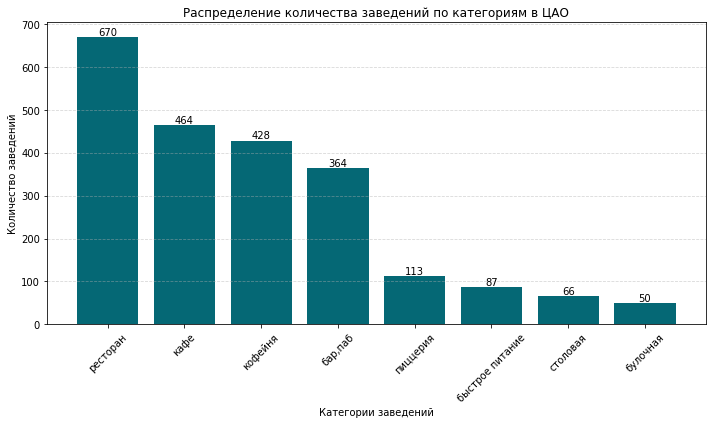

In [37]:
# Подготавливаем данные для графика
categories = category_counts_cao['category']
counts = category_counts_cao['count']

# Создаём фигуру и оси
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color='#056875')

# Добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # координата X — центр столбца
        height,                             # координата Y — высота столбца
        f'{int(height)}',                   # текст метки
        ha='center',                        # горизонтальное выравнивание
        va='bottom',                        # вертикальное выравнивание (чуть ниже верхушки)
        fontsize=10
    )

# Оформление
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
plt.title('Распределение количества заведений по категориям в ЦАО')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Выводим график
plt.show()

В ЦАО доминируют рестораны (почти 30 % рынка) и кафе (более 20 %), вместе они формируют почти половину предложения; значимую долю также занимают кофейни и бары/пабы (в сумме свыше 35 %). Менее представлены нишевые и бюджетные сегменты (пиццерии, быстрое питание, столовые, булочные).

[Назад к содержанию](#start)

---

<a id='8'></a>
***3.3 Соотношение сетевых и несетевых заведений***

Изучим доли сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

In [38]:
# Распределяем заведения по столбцу chain  
overall_chain = df['chain'].value_counts().rename({0: 'Несетевые', 1: 'Сетевые'})

In [39]:
# Считаем доли 
overall_share = (overall_chain / len(df) * 100).round(2)

In [40]:
# Выводим результат
print('Доля заведений в целом:')
overall_share

Доля заведений в целом:


Несетевые    61.88
Сетевые      38.12
Name: chain, dtype: float64

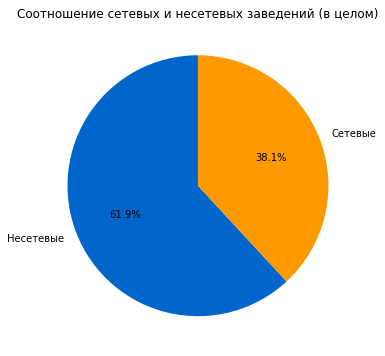

In [41]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(6, 6))

# Строим круговую диаграмму
plt.pie(overall_chain, labels=overall_chain.index, 
        autopct='%1.1f%%', # формат процентов внутри секторов
        startangle=90, # поворот: 90°
        colors=['#0066cc', '#ff9900'] # настройка цвета
)

# Оформление названия
plt.title('Соотношение сетевых и несетевых заведений (в целом)')

# Выводим график
plt.show()

На московском рынке общепита преобладают несетевые заведения - 61.9%, тогда как доля сетевых форматов составляет 38.1%, однако реальная доля может быть выше из‑за ошибок разметки для малых сетей.

Посмотрим распределение сетевых заведений по категорииям.

In [42]:
# Распределение сетевых заведений в разрезе категорий
chain_by_category = (
    df.groupby('category')['chain']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'сетевые_count', 'count': 'всего_count'})
)

In [43]:
# Считаем доли
chain_by_category['доля_сетевых_%'] = (chain_by_category['сетевые_count'] / chain_by_category['всего_count'] * 100).round(2)

In [44]:
# Сортируем в порядке убывания долей 
chain_by_category_sort = chain_by_category.sort_values('доля_сетевых_%', ascending=False)

chain_by_category_sort

,сетевые_count,всего_count,доля_сетевых_%
category,,,
булочная,157.0,256,61.33
пиццерия,330.0,633,52.13
кофейня,720.0,1413,50.96
быстрое питание,232.0,603,38.47
ресторан,729.0,2042,35.70
кафе,779.0,2377,32.77
столовая,88.0,315,27.94
"бар,паб",168.0,764,21.99


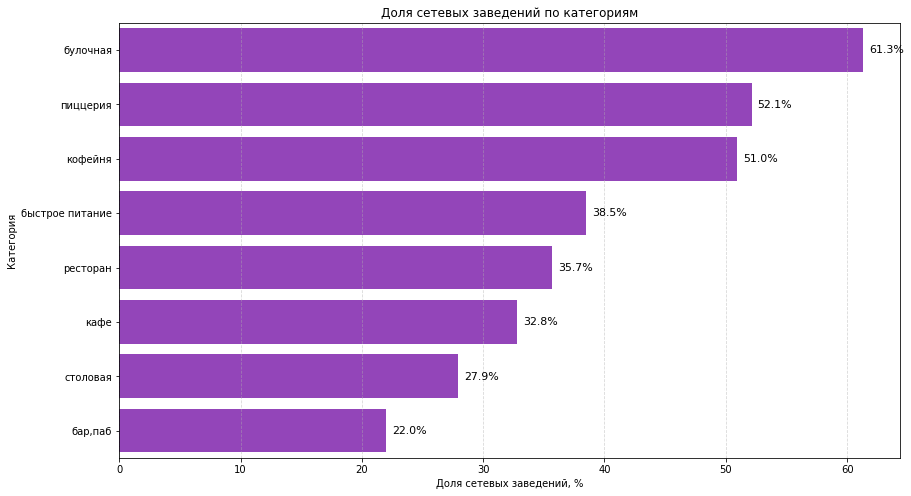

In [45]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(14, 8))

# Строим столбчатую диаграмму 
ax = sns.barplot(
    data=chain_by_category_sort.reset_index(),
    x='доля_сетевых_%',
    y='category',
    color='darkorchid'
)

# Настраиваем оформление графика
plt.xlabel('Доля сетевых заведений, %')
plt.ylabel('Категория')
plt.title('Доля сетевых заведений по категориям')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Добавляем подписи значений на столбцы
for i, patch in enumerate(ax.patches):
    width = patch.get_width()  # длина столбца (значение доли)
   
    ax.text(
        width + 0.5,               # x: значение + небольшой отступ
        patch.get_y() + patch.get_height() / 2,  # y: центр по вертикали
        f'{width:.1f}%',           # текст: значение с одним знаком после запятой и знаком %
        va='center',               # вертикальное выравнивание по центру
        fontsize=11                # размер шрифта
    )

# Выводим график 
plt.show()

Наибольшая доля сетевых заведений зафиксирована в сегменте булочных (61.3 %), за ними следуют пиццерии (52.1 %) и кофейни (51.0 %). Это указывает на высокую стандартизируемость и масштабируемость этих форматов. В сегментах ресторанов, кафе и баров доля сетей ниже (22–36 %), что говорит о большей ориентации на уникальность концепции.

[Назад к содержанию](#start)

---

<a id='9'></a>
***3.4 Исследование количества посадочных мест в заведениях***

Посмотрим общие метрики и наличие аномальных значений или выбросов

In [46]:
# Изучаем статистические показатели столбца seats
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

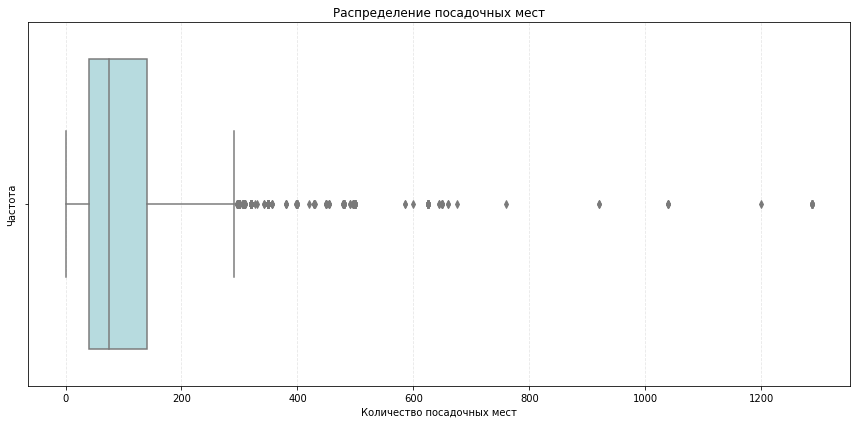

In [47]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(12, 6))

# Строим диаграмму размаха значений в столбце score
sns.boxplot(data=df, x='seats', color='powderblue')

# Добавляем заголовки и метки сои
plt.title('Распределение посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Выводим график
plt.show()

По статистике среднее (108.4) почти в 1.5 раза больше медианы (75), а стандартное отклонение (122.8) сопоставимо со средним — это явный признак сильного перекоса из‑за выбросов.
Минимум = 0. Это почти наверняка ошибка или особенность заполнения. Скорее всего, это либо пропуск, который заменили нулём, либо «не указано». 
Максимум = 1288. Это явный выброс. В Москве единичные заведения с такой вместимостью бывают (крупные столовые на предприятиях, банкетные залы, фуд‑корты с общей зоной), но для типового формата это нерепрезентативно.
Разброс огромный: 25‑й перцентиль — 40 мест, 75‑й — 140. То есть «средние» 50 % заведений укладываются в диапазон 40–140 мест.
На диаграмме размаха отчётливо видны выбросы (точки за усами), включая экстремальное значение 1288 мест, также заметны нулевые значения у самого начала шкалы — они не соответствуют реальному формату заведений с посадкой.

In [48]:
# Группируем данные по категориям и смотрим описательную статистику
df.groupby('category')['seats'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",467.0,124.477516,145.162278,0.0,48.0,82.0,148.5,1288.0
булочная,148.0,89.385135,97.685844,0.0,25.0,50.0,120.0,625.0
быстрое питание,349.0,98.891117,106.611739,0.0,28.0,65.0,140.0,1040.0
кафе,1217.0,97.365653,117.922464,0.0,35.0,60.0,120.0,1288.0
кофейня,751.0,111.199734,127.837772,0.0,40.0,80.0,144.0,1288.0
пиццерия,427.0,94.496487,112.282703,0.0,30.0,55.0,120.0,1288.0
ресторан,1269.0,121.892041,123.792216,0.0,48.0,86.0,150.0,1288.0
столовая,164.0,99.750000,122.951453,0.0,40.0,75.5,117.0,1200.0


Во всех категориях присутствуют ***аномальные значения***: нулевые показатели вместимости и экстремально большие значения. Они связаны преимущественно с особенностями сбора и кодирования данных (пропуски, ошибки ввода) и специфическими форматами (фуд‑корты, крупные столовые, заведения на вынос). Для оценки типичной вместимости будем использовать медиану и интерквартильный размах и исключим нулевые значения.

In [49]:
# Исключаем нули 
df_no_zeros = df[df['seats'] > 0]

In [50]:
# Считаем границы выбросов по IQR
Q1 = df_no_zeros['seats'].quantile(0.25) # первый квартиль (25‑й перцентиль)
Q3 = df_no_zeros['seats'].quantile(0.75) # третий квартиль (75-Й перцентиль)
IQR = Q3 - Q1 # межквартильный размах
upper_bound = Q3 + 1.5 * IQR # верхняя граница для выбросов 

# нижняя граница не нужна, так как кол-во посадочных мест не может быть отрицательнам 

In [51]:
# Фильтруем выбросы
df_clean = df_no_zeros[(df_no_zeros['seats'] <= upper_bound)]

In [52]:
# Выводим результат
print(f'Было строк: {len(df)}')
print(f'Стало строк (без нулей): {len(df_no_zeros)}')
print(f'Строк после удаления выбросов: {len(df_clean)}')

Было строк: 8403
Стало строк (без нулей): 4656
Строк после удаления выбросов: 4338


In [53]:
# Группируем данные по категориям и считаем статистику
stats_by_cat = (
    df_clean
    .groupby('category')['seats']
    .agg(
        count='count', 
        median='median', 
        Q1=lambda s: s.quantile(0.25), 
        Q3=lambda s: s.quantile(0.75)
    )
    .reset_index()
    .sort_values('median', ascending=False)
)

In [54]:
# Добавим «диапазон типичных значений» как строку для удобства
stats_by_cat['typical_range'] = stats_by_cat.apply(
    lambda row: f"{int(row['Q1'])}–{int(row['Q3'])}", axis=1
)

In [55]:
# Выводим результат
stats_by_cat[['category', 'count', 'median', 'typical_range']]

,category,count,median,typical_range
6,ресторан,1155,80.0,48–130
0,"бар,паб",418,78.0,45–115
7,столовая,150,73.5,40–103
4,кофейня,672,70.0,40–120
2,быстрое питание,310,64.5,35–124
3,кафе,1106,60.0,38–100
1,булочная,131,50.0,32–120
5,пиццерия,396,50.0,30–100


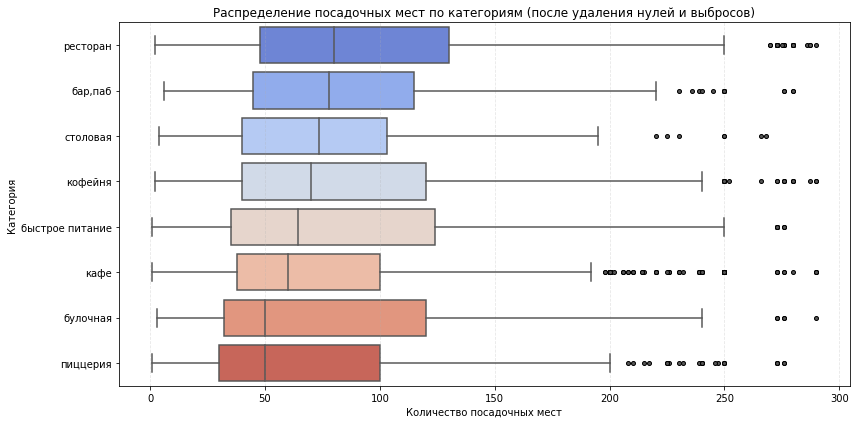

In [56]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(12, 6))

# Получаем список категорий в порядке убывания медианы
category_order = stats_by_cat['category'].tolist()

# Строим диаграмму размаха значений в столбце score по категориям
sns.boxplot(data=df_clean, x='seats', y='category', order=category_order, palette='coolwarm',
            flierprops=dict(marker='o', markersize=4, markeredgecolor='black'))

# Добавляем заголовки и метки сои
plt.title('Распределение посадочных мест по категориям (после удаления нулей и выбросов)')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Выводим график
plt.show()

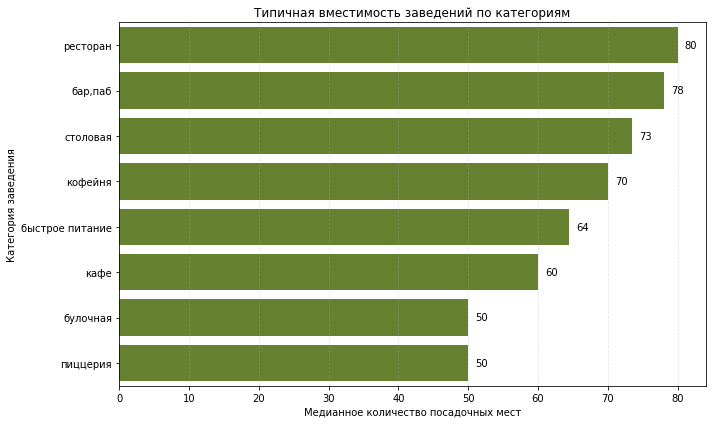

In [57]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
ax = sns.barplot(
    data=stats_by_cat,
    x='median',
    y='category',
    color='olivedrab'
)

# Подписываем значения на столбцах
for patch in ax.patches:
    width = patch.get_width()
    ax.text(
        width + 1,
        patch.get_y() + patch.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )
    
# Добавляем заголовки и метки оси
plt.xlabel('Медианное количество посадочных мест')
plt.ylabel('Категория заведения')
plt.title('Типичная вместимость заведений по категориям')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Выводим график
plt.show()

Рестораны и бары/пабы демонстрируют наибольшую вместимость (медианы 80 и 78 мест соответственно) при умеренном разбросе (50 % точек в диапазоне 45–130). Столовые, несмотря на стереотип «очень большие», по медиане (73,5 места) сопоставимы с барами, но имеют более широкий диапазон (40–103), что говорит о разнородности сегмента: есть как компактные столовые, так и крупные.
Компактные форматы (булочные, пиццерии, кафе) с медианами 50–60 мест и широкими диапазонами (например, у кофеен 40–120) дают больше гибкости по размещению.

[Назад к содержанию](#start)

---

<a id='10'></a>
***3.5 Распределение рейтинга заведений по категориям***

Исследуем распределение средних рейтингов по категориям заведений. 

In [58]:
# Группируем по категориям и считаем средний рейтинг, сортируем по убыванию рейтинга 
avg_rating_by_cat = (
    df.groupby('category')['rating']
      .mean()
      .round(2)
      .reset_index(name='avg_rating')
      .sort_values('avg_rating', ascending=False)
)

# Выводим результат
avg_rating_by_cat

,category,avg_rating
0,"бар,паб",4.39
5,пиццерия,4.30
6,ресторан,4.29
4,кофейня,4.28
1,булочная,4.27
7,столовая,4.21
3,кафе,4.12
2,быстрое питание,4.05


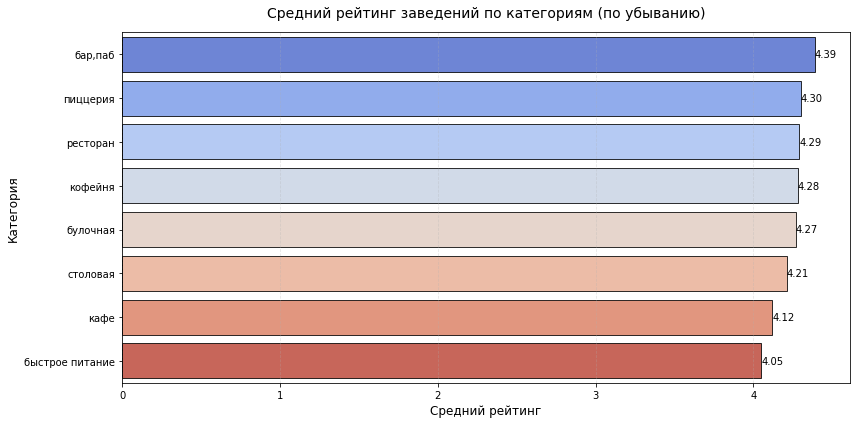

In [59]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму
ax = sns.barplot(
    data=avg_rating_by_cat,
    x='avg_rating',
    y='category',
    palette='coolwarm',
    edgecolor='black',
    linewidth=0.8
)

# Подписываем значения на столбцах
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.2f}',
        xy=(width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Оформление
plt.title('Средний рейтинг заведений по категориям (по убыванию)', fontsize=14, pad=15)
plt.xlabel('Средний рейтинг', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Выводим график
plt.show()

Средний рейтинг по категориям варьируется в узком диапазоне — от 4.05 до 4.39. Лидер — сегмент "бар/паб" (4.39), аутсайдер — "быстрое питание" (4.05). Небольшой разброс подтверждает, что высокий уровень удовлетворённости клиентов достижим в любом формате при грамотной организации сервиса.

[Назад к содержанию](#start)

---

<a id='11'></a>
***3.6 Изучение корреляции между рейтингом заведений и другими данными***

Рассчитаем матрицу корреляции phi_k для рейтингов заведений с разными данными: категория заведения, расположение, статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. 

In [60]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.281392
district,0.200701
category,0.189904
is_24_7,0.150210
chain,0.108060
seats,0.000000


Наибольшая корреляция рейтинга заведений наблюдается с ценовыми категориями (0.28) и расположением (0.20). Для остальных признаков коэффициент корреляции снижается с 0.19 до 0.

Визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

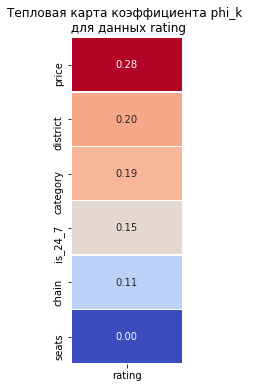

In [61]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')

# Выводим график
plt.show()

Для оценки самой сильной связи между ценовой категорией и рейтингом построим сводную таблицу со средними и медианными значениями, а также количеством заведений в каждой категории.

In [62]:
# Группируем данные по price и считаем статистику
price_agg = df.groupby('price')['rating'].agg(
    ['mean', 'median', 'std', 'count']).round(2).rename(
    columns={'mean': 'Средний рейтинг', 
             'median': 'Медианный рейтинг', 
             'std': 'Стд. отклонение', 
             'count': 'Число заведений'})

# Выводи результат
price_agg

,Средний рейтинг,Медианный рейтинг,Стд. отклонение,Число заведений
price,,,,
высокие,4.44,4.4,0.31,478
выше среднего,4.39,4.4,0.22,564
не известно,4.17,4.3,0.55,5088
низкие,4.17,4.2,0.37,156
средние,4.30,4.3,0.30,2117


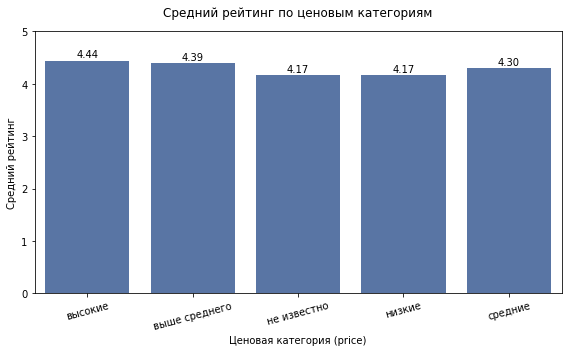

In [63]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(8, 5))

# Строим столбчатую диаграмму
ax = sns.barplot(
    data=price_agg.reset_index(),
    x='price',
    y='Средний рейтинг',
    color='#4c72b0'
)

# Подписи значений на столбцах
for patch in ax.patches:
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height + 0.02,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Оформление
plt.title('Средний рейтинг по ценовым категориям', pad=15)
plt.xlabel('Ценовая категория (price)')
plt.ylabel('Средний рейтинг')
plt.ylim(0, 5)  # фиксируем шкалу 0–5 для наглядности
plt.xticks(rotation=15)
plt.tight_layout()

# Выводим график
plt.show()

Наиболее высоко оцениваемые заведения сосредоточены в ценовых сегментах "высокие" и "выше среднего". При этом большая часть рынка формально не имеет проставленной ценовой категории ("не известно"), и её средний рейтинг заметно ниже. Сегмент "средние" — самый крупный среди явно классифицированных и демонстрирует стабильно хороший уровень оценок.

[Назад к содержанию](#start)

---

<a id='12'></a>
***3.7 Топ-15 популярных сетей в Москве***

Найдем 15 самых популярных сетей в Москве (по количеству заведений), посчитаем для них значения среднего рейтинга и посмотрим к какой категории эти сети относятся.

In [64]:
# Фильтруем сетевые заведения
df_chain = df[df['chain'] == 1]

In [65]:
# Группируем по name, считаем средний рейтинг и берём первую категорию
chain_stats = (
    df_chain.groupby('name').agg(
        count_stores=('name', 'size'),
        avg_rating=('rating', 'mean'),
        category=('category', 'first')
    ).round(2).reset_index()
)

In [66]:
# Топ‑15 по популярности (по числу заведений)
top_15_chains = chain_stats.sort_values('count_stores', ascending=False).head(15)
top_15_chains

,name,count_stores,avg_rating,category
746,Шоколадница,120,4.18,кофейня
344,Домино'с Пицца,76,4.17,пиццерия
340,Додо Пицца,74,4.29,пиццерия
148,One Price Coffee,71,4.06,кофейня
759,Яндекс Лавка,69,3.87,ресторан
59,Cofix,65,4.08,кофейня
170,Prime,50,4.12,ресторан
679,Хинкальная,44,4.32,быстрое питание
378,КОФЕПОРТ,42,4.15,кофейня
431,Кулинарная лавка братьев Караваевых,39,4.39,кафе


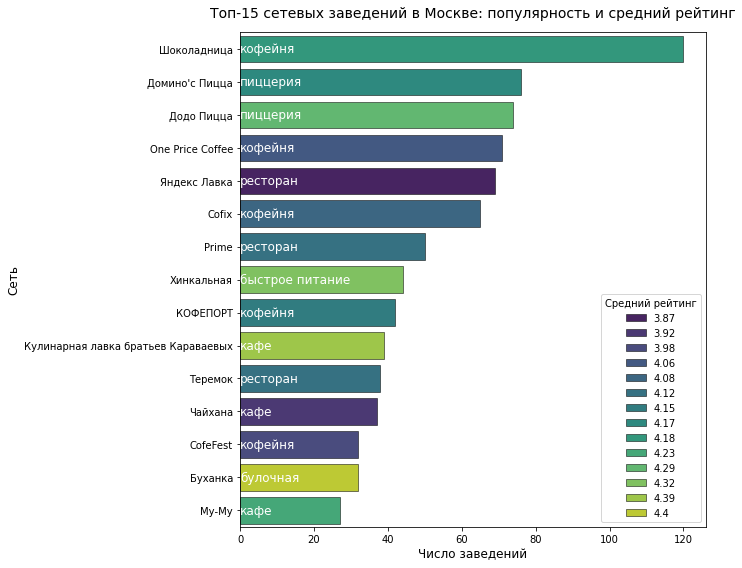

In [67]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(10, 8))

# Создаем столбчатую диаграмму
sns.barplot(
    data=top_15_chains,
    y='name',
    x='count_stores',
    hue='avg_rating',
    palette='viridis',
    dodge=False,
    edgecolor='black',
    linewidth=0.5
)

# Добавляем подписи с категориями
for i, (name, category) in enumerate(zip(top_15_chains['name'], top_15_chains['category'])):
    plt.text(0.01, i, category, color='w', fontsize=12, va='center')

# Оформление 
plt.title('Топ‑15 сетевых заведений в Москве: популярность и средний рейтинг', fontsize=14, pad=15)
plt.xlabel('Число заведений', fontsize=12)
plt.ylabel('Сеть', fontsize=12)
plt.legend(title='Средний рейтинг')
plt.tight_layout()

# Выводи график
plt.show()

Самай крупная сеть в топе - "Шоколадница" (120 точек, кофейня). Кофейни — самый частый формат среди топ‑сетей (Шоколадница, One Price Coffee, Cofix, КОФЕПОРТ, CofeFest). Это говорит о высокой плотности конкуренции в сегменте. Пиццерии — второй крупный кластер по масштабу (Домино’с, Додо). Это показывает, что сегмент пиццы в Москве хорошо масштабируется сетевым форматом. Остальные сети и категории значительно меньше.

[Назад к содержанию](#start)

---

<a id='13'></a>
***3.8 Зависимость среднего чека от района Москвы***

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Как мы знаем 62,5% строк в `middle_avg_bill` не имеют среднего чека, то есть любые средние по всем строкам будут сильно смещены. Поэтому для анализа цен берём только непустые значения.

In [68]:
# Оставляем только строки с известным средним чеком
df_complete = df[df['middle_avg_bill'].notna()]

In [69]:
# Посмотрим статистику 
df_complete['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Минимальное значение = 0 скорее всего ошибка при заполнении карточки заведения, максимальное значение = 35000 явно выброс. Эти значения сильно искажают среднее и стандартное отклонение. Посмотри что это за заведения и сколько их.

In [70]:
# Отфильтруем заведения со средним чеком равным нули и средним чеком больше 10000
df_complete[(df_complete['middle_avg_bill'] >= 10000) | (df_complete['middle_avg_bill'] == 0)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,name_norm,is_24_7
730,8ce8586978ff40d59375f65ef90757c2,Чойхона,"бар,паб","Москва, Дмитровское шоссе, 95А",Северный административный округ,"ежедневно, 10:00–23:00",4.4,0,49,высокие,Средний счёт:5000–17000 ₽,11000.0,NaN,чойхона,False
3685,502d91289bc5470eabd77fd77cc79821,Кофемания,кофейня,"Москва, улица Новый Арбат, 19",Центральный административный округ,"ежедневно, круглосуточно",4.5,1,200,высокие,Средний счёт:от 0 ₽,0.0,NaN,кофемания,True
5478,b73dde11d59e435d98d3004a614a9c3f,Гости,ресторан,"Москва, шоссе Энтузиастов, 52",Восточный административный округ,"пн,вс 18:00–22:30",4.1,0,<NA>,высокие,Средний счёт:5000–15000 ₽,10000.0,NaN,гости,False
7174,07b4e95afe8b4d299f823dc4f9de6df5,Кафе,ресторан,"Москва, Каширское шоссе, 23, стр. 2",Южный административный округ,"ежедневно, круглосуточно",4.1,0,100,высокие,Средний счёт:20000–50000 ₽,35000.0,NaN,кафе,True


Заведения со средним чеком больше 10000 действительно возможны, однако для анализа среднего чека по районам их лучше исключить из анализа. Это сделает сравнение районов более стабильным.

In [71]:
# Исключаем 0 и значения >= 10000
df_clean = df_complete[
    (df_complete['middle_avg_bill'] > 0) &
    (df_complete['middle_avg_bill'] < 10000)
]

In [72]:
# Считаем средний чек по районам
avg_bill_by_district = (df_clean.groupby('district')['middle_avg_bill'].agg(
        mean='mean',
        std='std',
        median='median',
        count='count'
    ).round(2).reset_index()
    .sort_values('mean', ascending=False)
)

# Выводим результат
avg_bill_by_district 

,district,mean,std,median,count
5,Центральный административный округ,1192.18,919.72,1000.0,1059
1,Западный административный округ,1053.23,779.01,1000.0,306
2,Северный административный округ,896.58,719.34,650.0,321
4,Северо-Западный административный округ,822.22,595.06,700.0,157
7,Юго-Западный административный округ,792.56,559.17,600.0,235
0,Восточный административный округ,785.19,631.66,550.0,259
8,Южный административный округ,725.24,542.50,500.0,313
3,Северо-Восточный административный округ,716.61,591.23,500.0,301
6,Юго-Восточный административный округ,654.10,566.83,450.0,194


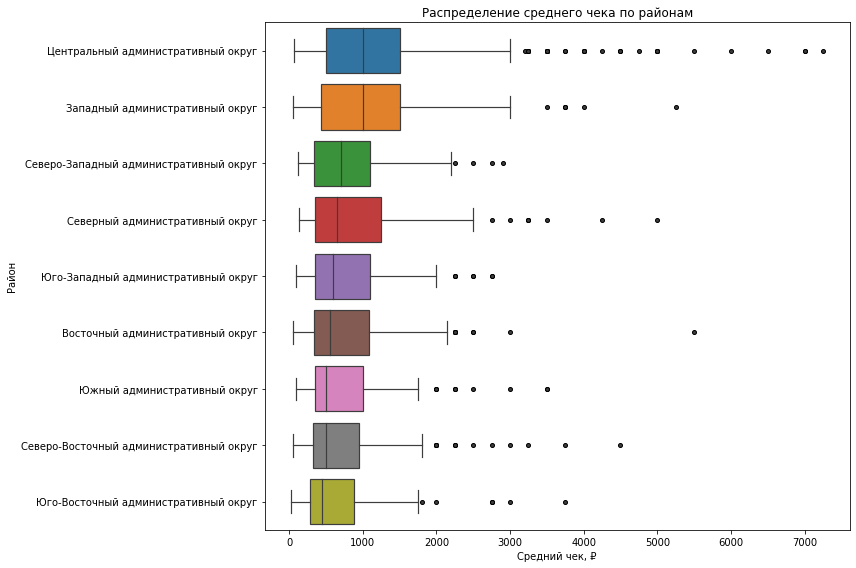

In [73]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(12, 8))

# Формируем порядок районов по убыванию медианы
median_order = avg_bill_by_district.sort_values('median', ascending=False)['district'].tolist()

# Строим диаграмму размаха значений среднего чека по районам
sns.boxplot(
    data=df_clean,
    y='district',
    x='middle_avg_bill',
    order=median_order,
    showfliers=True,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, markeredgecolor='black')
)

# Добавляем заголовки и метки оси
plt.title('Распределение среднего чека по районам')
plt.xlabel('Средний чек, ₽')
plt.ylabel('Район')
plt.tight_layout()

# Выводим график
plt.show()

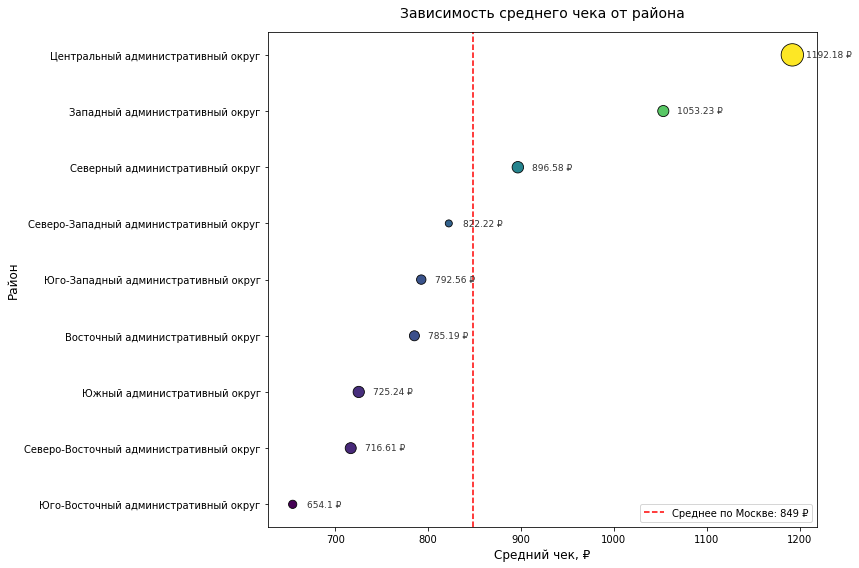

In [74]:
# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(12, 8))

# Scatter plot: точки — средний чек, размер точки — количество заведений (count)
scatter = sns.scatterplot(
    data=avg_bill_by_district,
    x='mean',
    y='district',
    size='count',
    sizes=(50, 500),          # диапазон размеров точек
    hue='mean',              # цвет по величине среднего чека
    palette='viridis',
    edgecolor='black',
    linewidth=0.8,
    legend=False
)

# Добавляем заголовки и метки оси
plt.title('Зависимость среднего чека от района', fontsize=14, pad=15)
plt.xlabel('Средний чек, ₽', fontsize=12)
plt.ylabel('Район', fontsize=12)

# Добавим подписи значений среднего чека рядом с точками
for _, row in avg_bill_by_district.iterrows():
    plt.text(
        row['mean'] + 15,
        row['district'],
        f"{row['mean']} ₽",
        va='center',
        fontsize=9,
        color='#333333'
    )

# Добавим вспомогательную вертикальную линию для наглядности (среднее по Москве)
overall_mean = avg_bill_by_district['mean'].mean()
plt.axvline(overall_mean, color='red', linestyle='--', linewidth=1.5, label=f'Среднее по Москве: {overall_mean:.0f} ₽')
plt.legend(loc='lower right')

plt.tight_layout()

# Выводим график
plt.show()

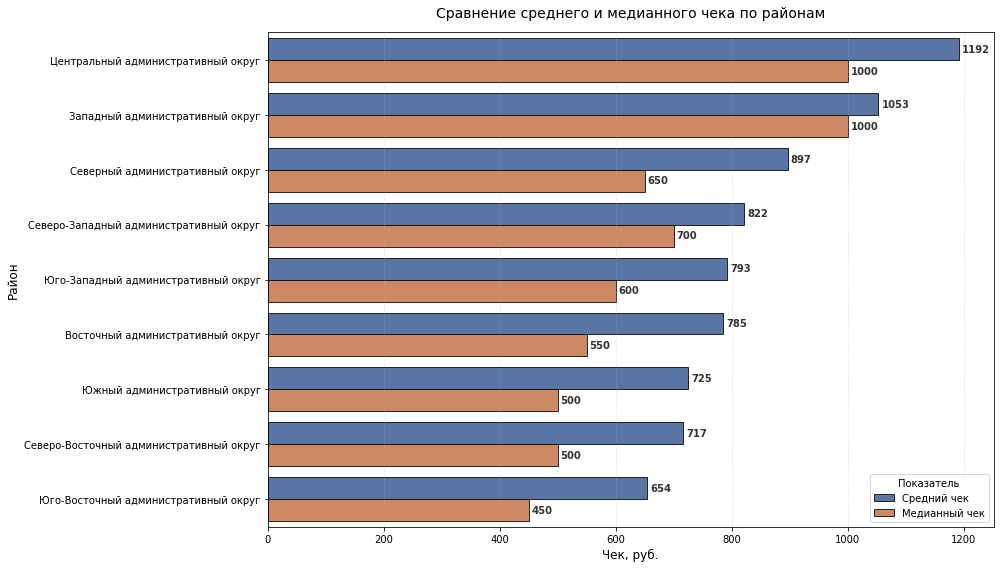

In [75]:
# Превращаем mean и median в длинный формат: одна колонка со значением, одна — с типом метрики
melted = avg_bill_by_district.melt(
    id_vars='district',
    value_vars=['mean', 'median'],
    var_name='metric',
    value_name='amount'
)

# Перекодируем для понятной легенды
melted['metric_label'] = melted['metric'].map({'mean': 'Средний чек', 'median': 'Медианный чек'})

# Создаём контейнер графика и задаём его размер
plt.figure(figsize=(14, 8))

# Строим диаграмму
ax = sns.barplot(
    data=melted,
    y='district',                
    x='amount',                    
    hue='metric_label',           
    palette={'Средний чек': '#4c72b0', 'Медианный чек': '#dd8452'},
    edgecolor='black',
    linewidth=0.8
)

# Подписи значений на столбцах: 
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.0f}',
        xy=(width + 5, p.get_y() + p.get_height() / 2),  
        ha='left',
        va='center',
        fontsize=10,                                      
        color='#333333',
        fontweight='bold'                                 
    )
        
plt.title('Сравнение среднего и медианного чека по районам', fontsize=14, pad=15)
plt.xlabel('Чек, руб.', fontsize=12)
plt.ylabel('Район', fontsize=12)
plt.legend(title='Показатель', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

Диаграмма размаха подтверждает, что Центральный административный округ — лидер по уровню цен: медиана и межквартильный размах там существенно выше, чем в других округах. При этом в ЦАО наблюдается максимальная вариативность: широкий разброс цен и большое количество заведений‑выбросов с высоким чеком.
В удалённых округах (например, Юго‑Западный, Южный) цены ниже и более однородны: «ящики» компактнее, выбросов меньше.
Наличие выбросов во всех округах говорит о том, что премиальный сегмент присутствует не только в центре, но и на периферии.

Диаграмма рассеивания показывает чёткий тренд снижения чека по мере удаления от центра.
После ЦАО идёт Западный округ (≈1050 ₽), затем Северный (≈900 ₽), далее округа с чеком 800–850 ₽, и на последнем месте — Юго‑Восточный округ с чеком ≈650 ₽. 

При сравнении среднего и медианного чека можно заметить превышение среднего чека над медианным во всех округах. Это говорит о правосторонней асимметрии распределения чеков: в каждом округе есть заведения с существенно более высокими чеками, которые «тянут» среднее вверх.

---


***ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ:***
* Рынок общепита Москвы представлен 8 категориями. Крупнейшие сегменты: кафе (28.3%), рестораны (24.3%) и кофейни (16.8%). 
* Рынок поделен на 8 административных округов, помимо ЦАО. Каждый из них занимает долю в диапазоне 8,4–10,7 %. Исключение — Северо‑Западный АО (4,9 %), где плотность заведений заметно ниже.
* В ЦАО доминируют рестораны, кафе, кофейни (почти 70%), барно-пивная культура также крайне развита, занимая четвертое место с долей более 16%, остальные 15% представлены более бюджетными категориями (пиццерии, бистро, столовые, булочные).
* Большинство рынка формируют несетевые заведения (61.9%), что говорит о востребованности локальных точек с индивидуальной концепцией. Сетевые модели наиболее активно развиваются в форматах с типовой концепцией и высокой повторяемостью спроса: булочные (61.3 %), пиццерии (52.1 %), кофейни (51.0 %).
* Рынок четко делится на два масштаба: премиальные рестораны (медиана 80 мест) почти в полтора раза крупнее массового сегмента — кафе и пиццерий (медианы 60 и 50 мест соответственно). При этом самый широкий разброс по количеству мест наблюдается у заведений быстрого питания (диапазон 35–124 места), что говорит о максимальной гибкости формата от киоска до фуд-корта.
* Распределение рейтингов по категориям схожее: медианы лежат в узком коридоре 4.0–4.4, а диапазоны существенно перекрываются. Это значит, что высокий рейтинг достижим в любом сегменте — ключевой фактор успеха не тип заведения, а качество исполнения.
* Анализ корреляции показал наиболее сильную связь между рейтингом и ценовой категорией. Заведения с более высокой заявленной ценой получают в среднем более высокие оценки: тренд прослеживается от «низкие/не известно» (4.17) → «средние» (4.30) → «выше среднего/высокие» (4.39–4.44). Это может отражать как реальное качество сервиса, так и эффект ожиданий: в премиальном сегменте гости могут оценивать иначе, либо там более профессиональный сервис.
* В Москве доминируют кофейни (5 из 15 сетей, лидер «Шоколадница» — 120 точек), однако самый высокий средний рейтинг у нишевых форматов: «Буханка» (4.40) и «Хинкальная» (4.32). При этом лидеры по количеству заведений («Шоколадница», «Додо Пицца») имеют оценки ниже лидеров рейтинга (4.18–4.29 против 4.32–4.40).
* Центральный административный округ выделяется как зона с самым высоким средним чеком (1192 ₽) и наибольшей плотностью заведений (n=1059). По мере удаления от центра средний чек устойчиво снижается, достигая минимума в Юго‑Восточном округе (654 ₽).

[Назад к содержанию](#start)

---

# 4. Итоговые выводы

<a id='14'></a>
***4.1. Обзор проделанной работы***

В ходе исследования проанализировали данные 8403 заведений города Москвы из 9 административных округов. Данные включали категорию, ценовую политику, режим работы, количество посадочных мест, рейтинг у заведений. Была проведена последовательная очистка исходных данных от пропусков и дубликатов, также проведен исследовательский анализ для решения поставленных задач.   

<a id='15'></a>
***4.2. Ответы на исследовательские вопросы***

* На московском рынке общественного питания доминируют форматы с досуговой составляющей — кафе и рестораны (суммарно 52.6 %), что говорит о спросе на "место для времяпрепровождения", а не только на еду.
* Все административные округа, кроме Центрального и Северо-Западного, дают 8.5 - 10.7 % точек. Эти крупные периферийные округа обладают развитой инфраструктурой и высоким спросом, но значительно уступают центру, в ЦАО расположено почти в 2,5 раза больше заведений, чем на севере. Северо‑Западный АО (4,9 %) — потенциальная зона роста: низкая плотность заведений может означать меньшую конкуренцию и свободные ниши для новых форматов при условии проверки трафика и целевой аудитории. Распределение заведений крайне неравномерно и подчиняется классической моноцентрической модели развития городской инфраструктуры. Количество точек общепита напрямую коррелирует с плотностью деловой активности, туристическими потоками и транспортной доступностью районов. Центр выполняет функцию главного концентратора услуг, тогда как остальные округа обслуживают преимущественно локальные потребности жителей.
* Несетевые заведения формируют большинство рынка (61,88 %), что отражает специфику московского общепита — значительную роль локальных точек с индивидуальной концепцией. При этом доля сетевых игроков остаётся существенной (38,12 %), демонстрируя устойчивый спрос на стандартизированные форматы и возможности для масштабирования.
* Форматы, где покупатель ценит скорость, низкую цену и гарантированное стабильное качество (кофейня, пиццерия, булочная), почти наполовину и более состоят из сетей. Напротив, сегменты, где ключевыми факторами выбора являются атмосфера, уникальный опыт и авторская кухня (бары, рестораны, кафе), остаются полем деятельности для независимых предпринимателей.
* Количество посадочных мест напрямую зависит от целевого времени пребывания гостя. Чем дольше гость должен находиться в заведении (ресторан, бар), тем больше требуется пространства (медиана 80 и 78 мест соответствено). Чем быстрее концепция предполагает оборачиваемость стола или чем выше доля заказов навынос (пиццерия - 50 м, булочная - 50 м, быстрое питание - 65 м), тем компактнее проектируется залы. Данные также показывают, что даже внутри одной категории формат может варьироваться от микро-точки до крупного заведения.
* Анализ средних рейтингов показывает отсутствие выраженного доминирования какого‑либо формата: даже категории с наименьшими оценками удерживают показатель выше 4.0. При этом лидерство "баров/пабов" может быть связано с особенностями клиентского опыта в этом сегменте. Незначительная разница говорит о том, что конкурентное преимущество формируется не за счёт выбора формата, а за счёт качества исполнения операционных процессов.
* Прямая связь между ценой и качеством подтверждается данными, но она не является абсолютным правилом. Высокая цена служит фильтром, отсекающим некачественные продукты и обеспечивающим стабильный уровень сервиса, что выражается в высоком рейтинге и низкой волатильности оценок. Напротив, низкие и неопределенные ценовые сегменты характеризуются максимальной неоднородностью, где вероятность столкнуться как с выдающимся авторским местом, так и с крайне низким качеством обслуживания значительно выше.
* Сетевые заведения в Москве представлены в разных сегментах — от кофеен до булочных, при этом масштаб сети не гарантирует высокий рейтинг: лидеры по числу точек (кофейни, пиццерии) имеют стабильно хорошие, но не самые высокие оценки, тогда как нишевые проекты (булочные, кафе) нередко получают более высокие пользовательские оценки.
* Средний чек заметно выше в Центральном административном округе (почти 1200 руб.) и снижается по мере удаления от центра — в юго‑восточных и северо‑восточных округах он в среднем не превышает 720 руб.; при этом во всех районах высока вариативность цен, что говорит о разнородности заведений внутри округов.

<a id='16'></a>
***4.3. Рекомендации на основе анализа данных***

На основе анализа рынка общественного питания Москвы сформировали следующие рекомендации:

***1. Формат заведения.*** Рассмотрите два направления:
* масштабируемые сетевые форматы с предсказуемым спросом — кофейни, пиццерии, булочные (высокая доля сетей, стабильный трафик, быстрая оборачиваемость). Они совмещают скорость обслуживания с комфортной посадкой (городские кафе, монопродуктовые проекты вроде хинкальных). На них приходится более 50% рынка, и они закрывают базовый запрос горожан — «место для времяпрепровождения»;
* нишевые локальные проекты с уникальной концепцией — авторские кафе, рестораны, бары (высокий потенциал рейтинга и лояльности, востребованы в условиях доминирования несетевых точек). Однако этот формат плохо масштабируется, имеет низкую оборачиваемость стола.

***2. Расположение***
* Зона максимального риска: Центральный административный округ (ЦАО). Высокая плотность трафика, но рынок перегрет, стоимость аренды максимальна, а высокая вариативность чека указывает на поляризацию аудитории.
* Точка роста №1: Северо-Западный АО. Самая низкая плотность заведений (4,9%) и потенциально меньше конкуренции (обязательно проверить пешеходный трафик и целевую аудиторию).
* Точка роста №2: Крупные периферийные округа (СВАО, ЮВАО, ЮАО). Суммарно генерируют стабильный спрос. Стратегия здесь — не премиальность, а объем транзакций за счет расположения внутри жилых кластеров («у дома») или вблизи транспортных узлов.

***3. Ценовая политика***
* В центре ориентируйтесь на средний и выше среднего чек — это работает как фильтр качества и поддерживает стабильный рейтинг.
* В периферийных округах уместны более доступные сегменты, но с обязательным контролем качества: в низких ценовых сегментах высокая неоднородность и риск низких оценок.

***4. Меню и концепция***

* Для сетевых форматов делайте упор на стандартизацию, скорость и стабильное качество; для локальных — на атмосферу, уникальность и авторский подход. 
* Учитывайте целевое время пребывания гостя: для ресторанов и баров закладывайте больше посадочных мест (медиана 78–80), для быстрых форматов (пиццерии, булочные) — компактные залы (около 50–65 мест).

[Назад к содержанию](#start)